In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import math
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

from tqdm import tqdm

## Byte Pair Encoding (BPE)

1. separate each char in word by space and add mark end of token, count frequency of tokens in corpus.

In [3]:
def build_vocab(corpus):
  tokens = [" ".join(word) + " </w>" for word in corpus.split()]
  # count frequency of tokens in corpus
  vocab = Counter(tokens)
  return vocab

2. get counts of pairs of consecutive symbols(characters or sub-words)

In [4]:
def get_stats(vocab):
  pairs = Counter()
  for word, frequency in vocab.items():
    symbols = word.split()
    for i in range(len(symbols) - 1):
      pairs[symbols[i], symbols[i + 1]] += frequency
  return pairs

3. merge the most frequent pairs in the vocabulary

In [5]:
def merge_vocab(pair, v_in):
  v_out = Counter()
  bigram = re.escape(' '.join(pair))
  p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')

  for word, freq in v_in.items():
    w_out = p.sub(''.join(pair), word)
    v_out[w_out] = freq
  
  return v_out

example: creating a vocabualry out of all the works of William Shakespeare. we can adjust the num_merges parameter to control the granularity of tokens.

In [6]:
with open('AntonChekhov.txt', 'r') as f:
  corpus = f.read()

vocab = build_vocab(corpus)
num_merges = 4000
for i in tqdm(range(num_merges)):
  pairs = get_stats(vocab)
  if not pairs:
    break
  best = max(pairs, key=pairs.get)
  vocab = merge_vocab(best, vocab)

100%|██████████| 4000/4000 [00:36<00:00, 110.18it/s]


now lets take a peek into the tokens created from this corpus

In [7]:
def get_tokens_from_vocab(vocab):
  token_freq = Counter()
  tokenization = {}
  for word, freq in vocab.items():
    tokens = word.split()
    for token in tokens:
      token_freq[token] += freq
    tokenization[''.join(tokens)] = tokens
  return token_freq, tokenization

after merging 4000 times, we have generated 3936 tokens from our corpus

In [8]:
token_freq, tokenization = get_tokens_from_vocab(vocab)
print('Number of tokens: {}'.format(len(token_freq.keys())))
print('Most common 20 tokens: {}'.format(token_freq.most_common(10)))

Number of tokens: 3936
Most common 20 tokens: [('the</w>', 3279), ('and</w>', 2917), ('to</w>', 1888), ('a</w>', 1655), ('of</w>', 1580), ('in</w>', 1396), ('I</w>', 1231), ('was</w>', 1153), ('he</w>', 959), ('her</w>', 800)]


In [9]:
def print_vocab(vocab):
  for word, freq in vocab.most_common(10):
    print(f"{word}: {freq}")

print_vocab(vocab)

the</w>: 3271
and</w>: 2903
to</w>: 1884
a</w>: 1603
of</w>: 1579
in</w>: 1346
I</w>: 1227
was</w>: 1152
he</w>: 954
her</w>: 795


Now lets create the mapping of tokens to integers and back.

In [10]:
def token_length(token):
  return len(token[:-4]) + 1 if token[-4:] == '</w>' else len(token)

def sort_key(item):
  return (token_length(item[0]), item[1])

sorted_tokens = [
  token
  for (token, freq) in sorted(
    token_freq.items(),
    key=sort_key,
    reverse=True,
  )
]


We also create two special tokens: unknown (</u>) which is used when a token is not present in our vocabulary and padding (</p>) which helps us create fixed length arrays of tokens to use as input.

In [11]:
UNK_TOKEN = '</u>'
PAD_TOKEN = '</p>'

token2id = {UNK_TOKEN:0, PAD_TOKEN:1}

for i, token in enumerate(sorted_tokens):
  token2id[token] = i + 2

id2token = {v:k for k, v in token2id.items()}

In [12]:
vocab_size = len(token2id)
vocab_size

3938

After building the vocabulary by merging most common subwords, use it to convert text to sequence of sub-words. We use </w> to denote that this token should be the end token of a word

In [13]:
def tokenize_words(s, sorted_tokens, unknown_token):  
  if not s:
    return []
  if not sorted_tokens:
    return [unknown_token]

  result = []
  for i, token in enumerate(sorted_tokens):
    
    pattern = re.escape(token)
    matches = [(m.start(), m.end()) for m in re.finditer(pattern, s)]

    if not matches:
      continue
    
    last = 0
    for start, end in matches:
      result += tokenize_words(s[last:start], sorted_tokens[i+1:], unknown_token)
      result.append(token)
      last = end

    result += tokenize_words(s[last:], sorted_tokens[i+1:], unknown_token)
    return result

  return result

def tokenize(text, sorted_tokens, token2id, return_str=False, max_len=32, unknown_token=UNK_TOKEN):
  text = " ".join([word + '</w>' for word in text.split(" ")])

  tokens = tokenize_words(text, sorted_tokens, unknown_token)
  if return_str: return tokens

  if max_len == -1: return [token2id[t] for t in tokens]
  ids = [1] * max_len
  attention_mask = [0] * max_len
  for i, t in enumerate(tokens):
      ids[i] = token2id[t]
      attention_mask[i] = 1
  return ids, attention_mask


Finally we can use our tokenzier to get token list and its corresponding integer list

In [14]:
max_len = 64

text = 'I am the first king of england'

tokenized = tokenize(text,
                     sorted_tokens=sorted_tokens,
                     token2id=token2id,
                     return_str=True,
                     max_len=max_len,
                     unknown_token=UNK_TOKEN)

print(tokenized)
print(sorted_tokens[:10])

['I</w>', 'am</w>', 'the</w>', 'first</w>', 'king</w>', 'of</w>', 'eng', 'l', 'and</w>']
['www.gutenberg.org/', 'www.gutenberg.org', 'drawing-room,</w>', 'extraordinary</w>', 'tax-collector</w>', 'conversations</w>', 'consciousness</w>', 'conversation</w>', 'drawing-room</w>', 'distributing</w>']


In [15]:
input_ids, attention_mask = tokenize(text,
                     sorted_tokens=sorted_tokens,
                     token2id=token2id,
                     return_str=False,
                     max_len=max_len,
                     unknown_token='</u>')
print(input_ids)
print(attention_mask)

[3534, 2873, 2110, 856, 1468, 2852, 3208, 3863, 2111, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


Now that we have a dynamic mapping of words into sub-words and their integers, we can use this representation with machines. However, these integers have semantic meaning, and we want to get rid of that.
For this, we create a mapping of integers to random vectors which are called word embeddings. We can give arbitrary dimension to these vectors, however the larger the dimension the more information they can encode and consequently increase the overall compute requirement for algorithms that use it.

In [16]:
emb_dim = 32

token_embeddings = nn.Embedding(vocab_size, emb_dim)
token_embeddings.weight.size() # vocab_size x embedding_dim

torch.Size([3938, 32])

In [17]:
with torch.no_grad():
  input_embeddings = token_embeddings(torch.Tensor(input_ids).long())

input_embeddings

tensor([[ 0.6070,  0.4538,  0.3638,  ..., -0.1912,  0.8724, -2.1072],
        [-0.3534, -0.1635, -0.5286,  ..., -1.1324,  0.3459,  0.6537],
        [-0.1615, -0.9664,  1.4362,  ..., -0.0347, -0.2379,  0.1903],
        ...,
        [-0.3915, -0.6100,  1.3824,  ...,  0.9361,  1.4474,  0.3141],
        [-0.3915, -0.6100,  1.3824,  ...,  0.9361,  1.4474,  0.3141],
        [-0.3915, -0.6100,  1.3824,  ...,  0.9361,  1.4474,  0.3141]])

In [18]:
input_embeddings.size() # max_len x embedding_dim

torch.Size([64, 32])

##  Positional Encoding

langugage is inherently sequential, and the order of the words/tokens is very important. we want to incorporate the position of the tokens in the sequence while modeling.

Positional encoding, the solution, adds a time signal to the input.

the ideal criteria for positional information encoding are:

1. it should output a unique encoding for each time-step
2. distance between any two time-steps should be consistent across sequences with different lengths.
3. our model should generalize to longer sentences without any efforts. Its values should be bounded.
4. it must be deterministic.

The proposed technique in the original 2017 paper is to generate a 
d dimensional vector PE such that *d*<sub>word embedding</sub> = *d*<sub>postional embedding</sub>
(one for each element of the sequence) and add it to the input vectors, defined as:

$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i / d_{model}}}\right), \quad
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i / d_{model}}}\right)
$$

where $pos$ represents the position of the word in the sequence, $d_{model}$ denotes the dimensionality of the positional encoding (PE), and $i$ indexes the embedding dimensions (in pairs), 

lets create matrix representing the positional encoding for $max\_len$ inputs.

In [19]:
pe = torch.zeros(max_len, emb_dim)
pe.size()

torch.Size([64, 32])

let’s implement the positional encoding formula to create position vectors for each position up to the max_len (context window) that our transformer is designed to handle.

In [20]:
position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
print(position.size())
print(position.T)

torch.Size([64, 1])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
         14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27.,
         28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41.,
         42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55.,
         56., 57., 58., 59., 60., 61., 62., 63.]])


In [21]:
div_term = torch.exp(torch.arange(0, emb_dim, 2).float() * (-math.log(10000.0) / emb_dim))
div_term.size()

torch.Size([16])

In [22]:
pos_sin = torch.sin(position * div_term)
pos_cos = torch.cos(position * div_term)
pos_sin.size(), pos_cos.size()

(torch.Size([64, 16]), torch.Size([64, 16]))

In [23]:
pe[:, 0::2] = pos_sin
pe[:, 1::2] = pos_cos
pe.size()

torch.Size([64, 32])

wrapping it all into a function, we have:

In [24]:
def position_encode(max_len, emb_dim):
  pe = torch.zeros(max_len, emb_dim)

  position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

  div_term = torch.exp(
      torch.arange(0, emb_dim, 2).float() * (-math.log(10000.0) / emb_dim)
  )

  pe[:, 0::2] = torch.sin(position * div_term)
  pe[:, 1::2] = torch.cos(position * div_term)

  return pe
  
position_encode(64, 32).size()

torch.Size([64, 32])

wwe can visualize the values of these positional encoding vectors as follows:

In [25]:
def plot_matrix(mat, xlabel, ylabel, figsize=(10, 10), ticklabels=None):
  fig, ax = plt.subplots(nrows=1, ncols=1, figsize=figsize)
  im = ax.imshow(mat, cmap='viridis')
  fig.colorbar(im)
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)
  if not ticklabels:
    ax.set_xticks([1]+[i*10 for i in range(1,1 + mat.shape[1]//10)])
    ax.set_yticks([1]+[i*10 for i in range(1,1 + mat.shape[0]//10)])
  else:
    ax.set_xticklabels(ticklabels[0])
    ax.set_yticklabels(ticklabels[1])
  plt.show()

we can observe that each position vector consists of periodic waves (sin/cos) of different frequency in each dimension, giving this interesting visualization

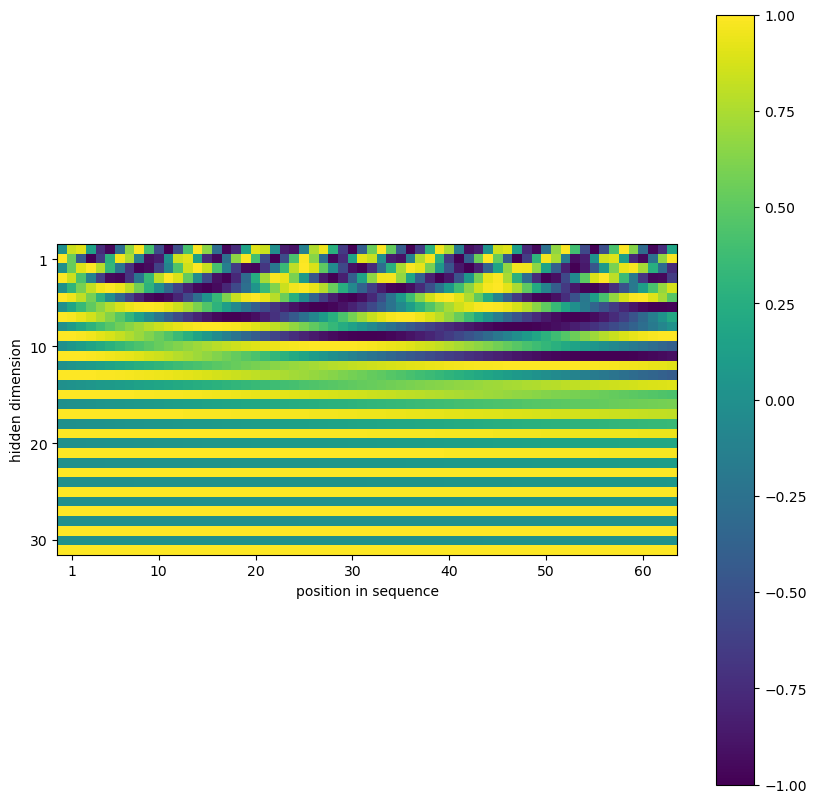

In [26]:
plot_matrix(pe.T.numpy(), xlabel="position in sequence", ylabel="hidden dimension")

finally, we add positional encoding to token embeddings to incorporate positional information.

In [34]:
x = input_embeddings + pe

with BPE and Positional encoding, we now have way to represent text as ordered numerical vectors. but how do we produce the output text? we can do this by outputing a probability distribution over the entire vocabulary size.

The following 2 layer neural network shows how we can input text into a neural network and get text out.

In [41]:
w1 = torch.randn(emb_dim, emb_dim, dtype=torch.float32)
b1 = torch.randn(emb_dim)

w2 = torch.randn(emb_dim, vocab_size, dtype=torch.float32)
b2 = torch.randn(vocab_size)

output = x @ w1 + b1
print(output.size())
output = nn.ReLU()(output)
print(output.size())

output = output @ w2 + b2
output = F.softmax(output, dim=-1)

torch.Size([64, 32])
torch.Size([64, 32])


In [48]:
output.argmax(1)

tensor([ 443,  830, 1157,  210, 3076, 2819, 2741,  243, 3036, 1485, 1485, 1485,
        2529, 1485, 3108, 3108, 1485, 1485, 1485, 1485,  470, 1485, 1485, 1485,
         203,  470,  470,  470,  470,  470, 1485,  894, 3108, 3108, 3108, 3108,
        3108, 3108, 3108, 3108, 3108,  754,  894,  894,  894, 3108, 3108, 2180,
        2180, 2180, 2180, 1485, 1485, 2180, 2180, 2180, 2180, 3108, 3108, 3108,
        3108, 3108, 1485, 3108])

In [49]:
print([id2token[i] for i in output.argmax(1).tolist()])

['right,"</w>', 'recogni', 'degrad', 'touching</w>', 'ue</w>', 'curi', 'coll', 'believed</w>', 'lac', 'most</w>', 'most</w>', 'most</w>', 'plat', 'most</w>', 'enc', 'enc', 'most</w>', 'most</w>', 'most</w>', 'most</w>', 'schoolbo', 'most</w>', 'most</w>', 'most</w>', 'question</w>', 'schoolbo', 'schoolbo', 'schoolbo', 'schoolbo', 'schoolbo', 'most</w>', 'white</w>', 'enc', 'enc', 'enc', 'enc', 'enc', 'enc', 'enc', 'enc', 'enc', 'monoton', 'white</w>', 'white</w>', 'white</w>', 'enc', 'enc', 'ses</w>', 'ses</w>', 'ses</w>', 'ses</w>', 'most</w>', 'most</w>', 'ses</w>', 'ses</w>', 'ses</w>', 'ses</w>', 'enc', 'enc', 'enc', 'enc', 'enc', 'most</w>', 'enc']
